# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Puspita
- **Email:** baharipuspita@apps.ipb.ac.id
- **ID Dicoding:** cdcc001d6x0224

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 Bagaimana pengaruh kondisi cuaca (weathersit) terhadap jumlah penyewaan sepeda? apakah penurunan penyewaan saat hujan ringan sangat drastis dibandingkan saat cerah?
- Pertanyaan 2 Apakah terdapat perbedaaan pola jam sibuk (hr) antara hari kerja (workingday) dan hari libur?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
#mengimport dataset day_df
day_df = pd.read_csv("https://raw.githubusercontent.com/pitaeoxo17-cloud/dataset-submission/refs/heads/main/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
#mengimport dataset hour_df
hour_df = pd.read_csv("https://raw.githubusercontent.com/pitaeoxo17-cloud/dataset-submission/refs/heads/main/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

mengimport dataset day_df dan hour_df, dataset tersebut memiliki feature yang sama, yang membedakannya hanya pada feature hr, feature hr hanya dimiliki oleh dataset our_df

### Assessing Data

Menilai Tabel day_df

In [4]:
#mengecek informasi pada dataset day_info
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
#melakukan pengecekan missing value pada tabel day_df
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [6]:
#melihat adanya duplikasi data pada dataset day_df
print("Jumlah duplikas:", day_df.duplicated().sum())

Jumlah duplikas: 0


In [7]:
#melihat ringkasan dari dataset day_df
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Menilai Tabel hour_df

In [8]:
#melakukan pengecekan adanya missing value pada dataset hour_df
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [9]:
#melakukan pengecekan adanya duplikasi pada dataset hour_df
print('Jumlah duplikasi:', hour_df.duplicated().sum())

Jumlah duplikasi: 0


In [10]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Tidak ada missing value pada kedua dataset
- Tidak ada duplikasi data pada kedua dataset
- Ada kesalahan pada dtype (object) dteday yang harusnya datetime, ini terjadi pada kedua dataset

### Cleaning Data

In [11]:
#Mengubah tipe data dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [12]:
#membuat kolom label dataset hour_df agar mudah dibaca pada tahap  EDA
day_df ['weather_label'] = day_df['weathersit'].map({
    1: 'Clear',
    2: 'Mist',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain'
})

#membuat label untuk kolom bulan
day_df['month_label'] = day_df['dteday'].dt.strftime('%B')

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,weather_label,month_label
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Mist,January
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,Mist,January
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Clear,January
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,Clear,January
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,Clear,January


In [13]:
#membersihkan tabel day_df
hour_df['dteday'] = pd.to_datetime(day_df['dteday'])

hour_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [14]:
#membuat kolom label dataset day_df agar mudah dibaca pada tahap  EDA
hour_df ['weather_label'] = hour_df['weathersit'].map({
    1: 'Clear',
    2: 'Mist',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain'
})

#membuat label untuk kolom bulan
hour_df['month_label'] = hour_df['dteday'].dt.strftime('%B')

hour_df.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,weather_label,month_label
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,Clear,January
1,2,2011-01-02,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,Clear,January
2,3,2011-01-03,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,Clear,January
3,4,2011-01-04,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,Clear,January
4,5,2011-01-05,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,Clear,January


**Insight:**
- Mengubah Dtype dteday (yang tadinya Dtype: object) pada dataset hour_df dan day_df menjadi datetime
- Menambahkan kolom weather_label dan month label pada kedua dataset untuk mempermudah pembacaan pada proses EDA
- Melakukan mapping
    1: 'Clear',
    2: 'Mist',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain'

## Exploratory Data Analysis (EDA)

### Explore dataset

In [15]:
# statistik day_df deskriptif berdasarkan cuaca
print(day_df.groupby('weathersit')['cnt'].describe())

            count         mean          std    min     25%     50%     75%  \
weathersit                                                                   
1           463.0  4876.786177  1879.483989  431.0  3636.5  4844.0  6458.5   
2           247.0  4035.862348  1809.109918  605.0  2674.5  4040.0  5257.5   
3            21.0  1803.285714  1240.284449   22.0   705.0  1817.0  2424.0   

               max  
weathersit          
1           8714.0  
2           8362.0  
3           4639.0  


**Insight**
- mengecek nilai mean dan max pada setiao kategori cuaca
- apakah ada perbedaan signifikan antara kategori 1(clear) dan 3 (Light Snow)? jika rata-rata turun > 50%, maka cuaca sangat berpengaruh secara drastis.

In [16]:
#jam sibuk pada hari kerja pada dataset workingday_df
workingday_stats = hour_df.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()

#melihat 5 jam dengan penyewaan tertinggi pada hari kerja
print('jam sibuk pada hari kerja:')
print(workingday_stats[workingday_stats['workingday'] == 1].sort_values(by='cnt', ascending=False).head(5))

#melihat 5 jam dengan penyewaan tertinggi pada hari libur
print("\njam sibuk pada hari libur:")
print(workingday_stats[workingday_stats['workingday'] == 0].sort_values(by='cnt', ascending=False).head(5))

jam sibuk pada hari kerja:
    workingday  hr         cnt
41           1  17  525.290581
42           1  18  492.226908
32           1   8  477.006048
43           1  19  348.401606
40           1  16  293.122244

jam sibuk pada hari libur:
    workingday  hr         cnt
13           0  13  372.731602
12           0  12  366.259740
14           0  14  364.645022
15           0  15  358.813853
16           0  16  352.727273


**Insight:**

Note:


1= workingday
0=weekend/holiday
- Pada hari kerja, apakah jam 8 pagi dan 5 sore adalah tertinggi? (megindikasikan pengguna komuter)
- pada hari libur, apakah penyewaan memuncak di siang hari jam 12-15? (berasumsi bahwa pengguna rekreasi)

## Visualization & Explanatory Analysis

### Pertanyaan 1:Bagaimana pengaruh kondisi cuaca (weathersit) terhadap jumlah penyewaan sepeda? apakah penurunan penyewaan saat hujan ringan sangat drastis dibandingkan saat cerah?

/tmp/ipykernel_4815/1447564469.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4815/1447564469.py:4: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.barplot(


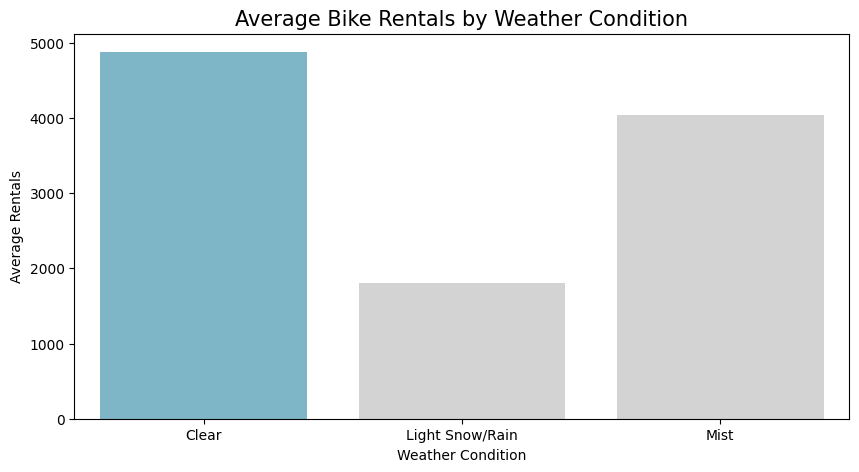

In [17]:
#melakukan visualisasi untuk menjawab pertanyaan pertama
weather_colors = ['#72BCD4', '#D3D3D3', '#D3D3D3', '#D3D3D3']
plt.figure(figsize=(10, 5))
sns.barplot(
    x='weather_label',
    y='cnt',
    data=day_df.groupby('weather_label')['cnt'].mean().reset_index(),
    palette= weather_colors)
plt.title('Average Bike Rentals by Weather Condition', fontsize=15)
plt.ylabel('Average Rentals')
plt.xlabel('Weather Condition')
plt.show()

**Insight**
- Cuaca sangat memengaruhi jumlah rata-rata rental sepeda. Rata-rata tertinggi berada pada cuaca cerah (clear); tertinggi ke-2 adalah cuaca berkabut tipis(Mist). Data menunjukkan adanya penurunan signifikan ketika cuaca hujana tau bersalju. Pada grafik ini tidak muncul Heavy Rain karena tidak ada data di dalamnya yang menunjukkan hal itu terjadi, tim yang menyediakan rental sepeda menutup rental sepedaa jika terjadi hal tersebut.

### Pertanyaan 2: Apakah terdapat perbedaaan pola jam sibuk (hr) antara hari kerja (workingday) dan hari libur?

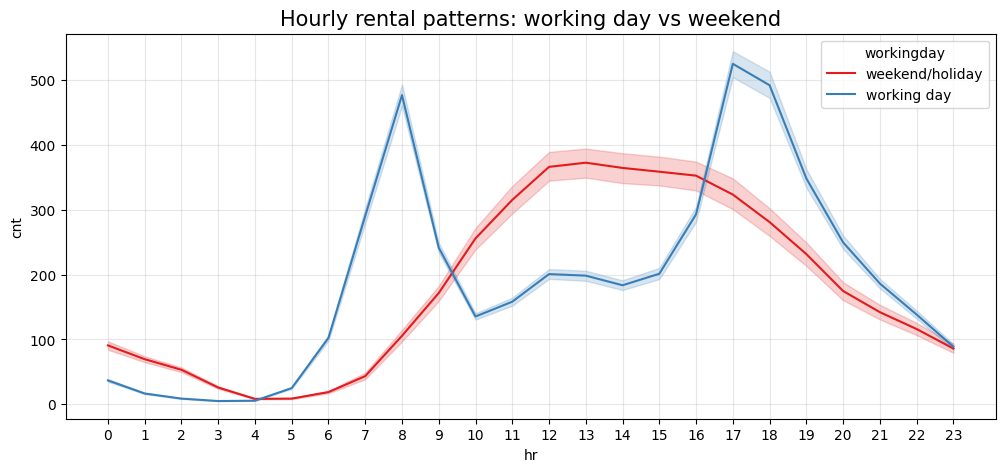

In [18]:
#membandingkan hari kerja vs libur
plot_df = hour_df.copy()
plot_df['workingday'] = plot_df['workingday'].map({1: 'working day', 0: 'weekend/holiday'})
plt.figure(figsize=(12, 5))
sns.lineplot(data=plot_df, x='hr', y='cnt', hue='workingday', palette='Set1')
plt.title('Hourly rental patterns: working day vs weekend', fontsize=15)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

**Insight:**
- Pada grafik ini data menunjukan jumlah rental terbanyak ketika hari kerja jam 5 sore dan 8 pagi. Pada hari weekend terbanyak pada jam 12:00 hingga 15:00.

## Analisis Lanjutan (Opsional)

In [19]:
#Binning waktu
def group_time(hour):
  if 5 <= hour < 12:
    return 'Morning'
  elif 12 <= hour < 17:
    return 'Afternoon'
  elif 17 <= hour < 21:
    return 'Evening'
  else:
    return 'Night'

hour_df['time_category'] = hour_df['hr'].apply(group_time)

#megatur urutan kategori dari morning-night
category_order = ['Morning', 'Afternoon', 'Evening', 'Night']
hour_df['time_category'] = pd.Categorical(hour_df['time_category'], categories=category_order, ordered=True)

/tmp/ipykernel_4815/26384685.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


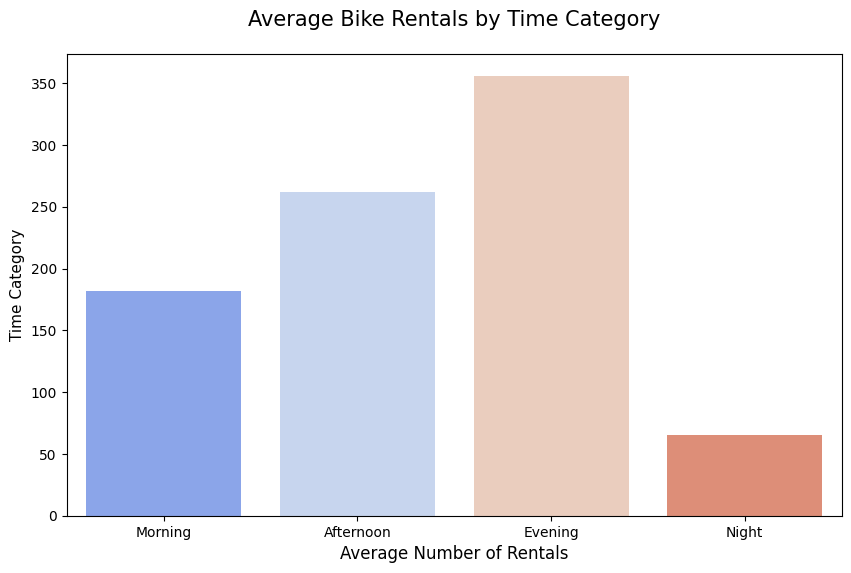

In [20]:
#melakukan visualisasi waktu tersibuk
plt.figure(figsize=(10, 6))
sns.barplot(
    x= 'time_category',
    y= 'cnt',
    data= hour_df,
    palette= 'coolwarm',
    errorbar= None
)

plt.title('Average Bike Rentals by Time Category', fontsize=15, pad=20)
plt.ylabel('Time Category', fontsize=11)
plt.xlabel('Average Number of Rentals', fontsize=12)
#plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [21]:
#menyimpan dataset untuk di up di dashboard
day_df.to_csv("all_data.csv", index=False)
hour_df.to_csv("all_hour.csv", index=False)

**Insight**

Dengan mengelompokkan jam ke dalam empat kategori (Morning, Afternoon, Evening, Night), kita dapat melihat aktivitas pengguna. Kategori Evening(sore) menempati posisi penyewaan tertinggi. Informasi ini sangat berguna bagi tim untuk memastikan ketersediaan unit sepedaa dan pemeliharaan fasilitas pada jam transisi dari siang ke sore hari

## Conclusion

- Conclution pertanyaan 1 Bagaimana pengaruh kondisi cuaca (weathersit) terhadap jumlah penyewaan sepeda? apakah penurunan penyewaan saat hujan/ bersalju sangat drastis dibandingkan saat cerah?

**Jawaban:**
Cuaca cerah adalah pendorong utama tingginya penyewaan, sementara hujan atau salju menjadi penghambat utama. Perusahaan dapat mempertimbangkan promosi khusus atau fasilitas tambahan, seperti menyediakan jas hujan untuk menjaga penyewa agar tetap terlindungi untuk menjaga volume penyewaan saat cuaca kurang mendukung

- Conclution pertanyaan 2 Apakah terdapat perbedaaan pola jam sibuk (hr) antara hari kerja (workingday) dan hari libur?

**Jawaban:**
Ya, terdapat pola perbedaan, saat working day jam sibuk berada pada jam 08:00 dan 17:00, ini mengindikasikan orang-orang beraktivitas untuk bekerja, di hari working day juga menjadi rata-rata rental sepeda tertinggi.

Pada hari weekend/holiday rental tertinggi mulai pada jam 12 siang dan cukup stabil sampai dengan jam 4 sore.
Berdasarkan pola tersebut distribusi sepeda harus diprioritaskan pada area pemukiman di sore hari dan padahari keja. Sedangkan pada akhir pekan bisa dialihkan ke area wisata atau taman pada siang hari.
